# DGA Signal Investigation (V2)

Controlled diagnostic stage. V1 remains unchanged; XGBoost uses the exact V1 configuration with no tuning. Asset and time are diagnostics only, not model features. The notebook examines label relationships, class overlap, assets, time, repeated CV, a repeated permutation control, unseen-asset and chronological checks, then an all-pass tuning gate.

In [4]:
# 2. Environment setup

import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
    "xgboost": "xgboost",
}

missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Environment ready.")
# 3. Imports and reproducibility

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

RANDOM_STATE = 42
N_PERMUTATIONS = 100

np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

Environment ready.


In [6]:
# ============================================================
# 1. Load and prepare data
# ============================================================

# Detect project root
root = (
    Path.cwd().parent
    if (Path.cwd().parent / "Data").exists()
    else Path.cwd()
)

DATA_PATH = root / "Data" / "dummy_dga_dataset.xlsx"

# Load dataset
df = pd.read_excel(DATA_PATH)

df

,row_id,asset,ts_H2,H2,C2H2,C2H4,C2H6,CH4,CO,CO2,ts_C2H2,ts_C2H4,ts_C2H6,ts_CH4,ts_CO,ts_CO2,R_C2H2_C2H4,R_CH4_H2,R_C2H4_C2H6,abnormal,triggers,status,fault_by_rogers
0,1,TX_A,2025-01-01 00:00:00,31.390939,0.882090,14.181881,4.206888,13.688683,599.963626,7332.511459,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,0.062198,0.436071,3.371110,False,NaN,Normal,Non-determinable
1,2,TX_B,2025-01-01 01:00:00,35.341884,0.507179,12.612538,6.345830,59.938383,557.168722,7240.401074,2025-01-01 01:00:00,2025-01-01 01:00:00,2025-01-01 01:00:00,2025-01-01 01:00:00,2025-01-01 01:00:00,2025-01-01 01:00:00,0.040212,1.695959,1.987532,False,NaN,Normal,Thermal Fault
2,3,TX_C,2025-01-01 02:00:00,65.635357,0.002433,24.096744,7.336242,38.569814,594.269670,9993.446821,2025-01-01 02:00:00,2025-01-01 02:00:00,2025-01-01 02:00:00,2025-01-01 02:00:00,2025-01-01 02:00:00,2025-01-01 02:00:00,0.000101,0.587638,3.284617,False,NaN,Normal,Partial Discharge
3,4,TX_B,2025-01-01 03:00:00,12.796451,0.537190,24.218719,16.563508,31.730099,776.015100,8341.712289,2025-01-01 03:00:00,2025-01-01 03:00:00,2025-01-01 03:00:00,2025-01-01 03:00:00,2025-01-01 03:00:00,2025-01-01 03:00:00,0.022181,2.479602,1.462173,False,NaN,Normal,Normal
4,5,TX_B,2025-01-01 04:00:00,48.779920,0.435549,22.021012,15.318398,33.244361,665.254346,8202.173810,2025-01-01 04:00:00,2025-01-01 04:00:00,2025-01-01 04:00:00,2025-01-01 04:00:00,2025-01-01 04:00:00,2025-01-01 04:00:00,0.019779,0.681517,1.437553,False,NaN,Normal,Non-determinable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,TX_B,2025-01-13 07:00:00,38.436584,0.941583,116.568558,17.140208,10.254530,554.412114,9412.724666,2025-01-13 07:00:00,2025-01-13 07:00:00,2025-01-13 07:00:00,2025-01-13 07:00:00,2025-01-13 07:00:00,2025-01-13 07:00:00,0.008078,0.266791,6.800883,True,C2H4 > 60,Abnormal,Non-determinable
296,297,TX_B,2025-01-13 08:00:00,68.783562,0.083984,123.787264,16.939372,49.277975,729.705083,8352.011208,2025-01-13 08:00:00,2025-01-13 08:00:00,2025-01-13 08:00:00,2025-01-13 08:00:00,2025-01-13 08:00:00,2025-01-13 08:00:00,0.000678,0.716421,7.307666,True,C2H4 > 60,Abnormal,Non-determinable
297,298,TX_B,2025-01-13 09:00:00,68.452776,0.686231,118.170440,7.745985,58.216605,641.567475,9436.443230,2025-01-13 09:00:00,2025-01-13 09:00:00,2025-01-13 09:00:00,2025-01-13 09:00:00,2025-01-13 09:00:00,2025-01-13 09:00:00,0.005807,0.850464,15.255702,True,C2H4 > 60,Abnormal,Non-determinable
298,299,TX_A,2025-01-13 10:00:00,73.190741,0.469285,114.271457,13.782449,6.612010,554.410884,9310.592976,2025-01-13 10:00:00,2025-01-13 10:00:00,2025-01-13 10:00:00,2025-01-13 10:00:00,2025-01-13 10:00:00,2025-01-13 10:00:00,0.004107,0.090339,8.291085,True,C2H4 > 60,Abnormal,Normal


In [7]:
# ------------------------------------------------------------
# Column definitions
# ------------------------------------------------------------

TARGET = "fault_by_rogers"
ASSET = "asset"
TIMESTAMP = "ts_H2"

RAW_FEATURES = [
    "H2",
    "C2H2",
    "C2H4",
    "C2H6",
    "CH4",
    "CO",
    "CO2",
]

RATIO_FEATURES = [
    "R_C2H2_C2H4",
    "R_CH4_H2",
    "R_C2H4_C2H6",
]

FEATURES = RAW_FEATURES + RATIO_FEATURES

In [8]:
# ------------------------------------------------------------
# Data preparation
# ------------------------------------------------------------

df[TIMESTAMP] = pd.to_datetime(df[TIMESTAMP])

classes = sorted(df[TARGET].unique())

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[TARGET])

labels = np.arange(len(classes))
X = df[FEATURES].copy()

In [9]:
# ------------------------------------------------------------
# Dataset summary
# ------------------------------------------------------------

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Time range: {df[TIMESTAMP].min()} → {df[TIMESTAMP].max()}")

print("\nTarget distribution:")

target_distribution = (
    df[TARGET]
    .value_counts()
    .rename("count")
    .to_frame()
)

target_distribution["proportion"] = (
    df[TARGET]
    .value_counts(normalize=True)
)

display(target_distribution.sort_index())

Rows: 300
Columns: 23
Time range: 2025-01-01 00:00:00 → 2025-01-13 11:00:00

Target distribution:


,count,proportion
fault_by_rogers,,
Non-determinable,63,0.210000
Normal,87,0.290000
Partial Discharge,76,0.253333
Thermal Fault,74,0.246667


### 2. Target relationship checks

### Diagnostic fields are inspected for potential relationships with the target.
### They are **not** used as model features.

In [10]:
# ============================================================
# 2. Target relationship checks
# ============================================================

print("=" * 70)
print("2. TARGET RELATIONSHIP CHECKS")
print("=" * 70)

diagnostic_fields = [
    "status",
    "abnormal",
    "triggers",
]

for column in diagnostic_fields:

    print(f"\n{column} by target")

    contingency = pd.crosstab(
        df[column].fillna("<missing>"),
        df[TARGET],
        normalize="index",
    )

    display(contingency.round(3))


# ------------------------------------------------------------
# Kruskal-Wallis + Mutual Information
# ------------------------------------------------------------

print("\nFeature-level statistical relationships")

mutual_information = mutual_info_classif(
    X,
    y,
    random_state=RANDOM_STATE,
)

results = []

for feature in FEATURES:

    groups = [
        group[feature].dropna()
        for _, group in df.groupby(TARGET)
    ]

    statistic, p_value = kruskal(*groups)

    epsilon_squared = max(
        0,
        (
            statistic - len(classes) + 1
        )
        / (
            len(df) - len(classes)
        ),
    )

    results.append(
        [
            feature,
            statistic,
            p_value,
            epsilon_squared,
        ]
    )


statistical_table = pd.DataFrame(
    results,
    columns=[
        "feature",
        "Kruskal_H",
        "p_unadjusted",
        "epsilon_squared",
    ],
)

statistical_table["mutual_information"] = mutual_information

statistical_table = statistical_table.sort_values(
    "epsilon_squared",
    ascending=False,
)

display(statistical_table.round(4))

print(
    "\nImportant:"
    "\nThese analyses can identify relationships in the supplied dataset,"
    "\nbut they cannot establish how the synthetic target was generated."
)

print(
    "\nProvider question:"
    "\nWhich DGA fields, rules, thresholds, transformations, or randomisation"
    "\nmechanisms generated `fault_by_rogers`, and were labels independent of DGA?"
)

2. TARGET RELATIONSHIP CHECKS

status by target


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
status,,,,
Abnormal,0.21,0.304,0.243,0.243
Normal,0.21,0.269,0.269,0.252



abnormal by target


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
abnormal,,,,
False,0.21,0.269,0.269,0.252
True,0.21,0.304,0.243,0.243



triggers by target


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
triggers,,,,
<missing>,0.21,0.269,0.269,0.252
C2H4 > 60,0.21,0.304,0.243,0.243



Feature-level statistical relationships


,feature,Kruskal_H,p_unadjusted,epsilon_squared,mutual_information
9,R_C2H4_C2H6,4.7522,0.1909,0.0059,0.0000
4,CH4,4.6635,0.1982,0.0056,0.0392
3,C2H6,3.7225,0.2930,0.0024,0.0000
0,H2,1.1182,0.7727,0.0000,0.0217
1,C2H2,2.2018,0.5316,0.0000,0.0000
2,C2H4,1.3640,0.7140,0.0000,0.0516
5,CO,1.3572,0.7156,0.0000,0.0050
6,CO2,1.6659,0.6445,0.0000,0.0000
7,R_C2H2_C2H4,2.2344,0.5252,0.0000,0.0000
8,R_CH4_H2,1.5524,0.6702,0.0000,0.0000



Important:
These analyses can identify relationships in the supplied dataset,
but they cannot establish how the synthetic target was generated.

Provider question:
Which DGA fields, rules, thresholds, transformations, or randomisation
mechanisms generated `fault_by_rogers`, and were labels independent of DGA?


### 3. Feature separability and PCA
### PCA is used strictly as a visual diagnostic.
### It is **not** used as a predictive model.

3. FEATURE SEPARABILITY


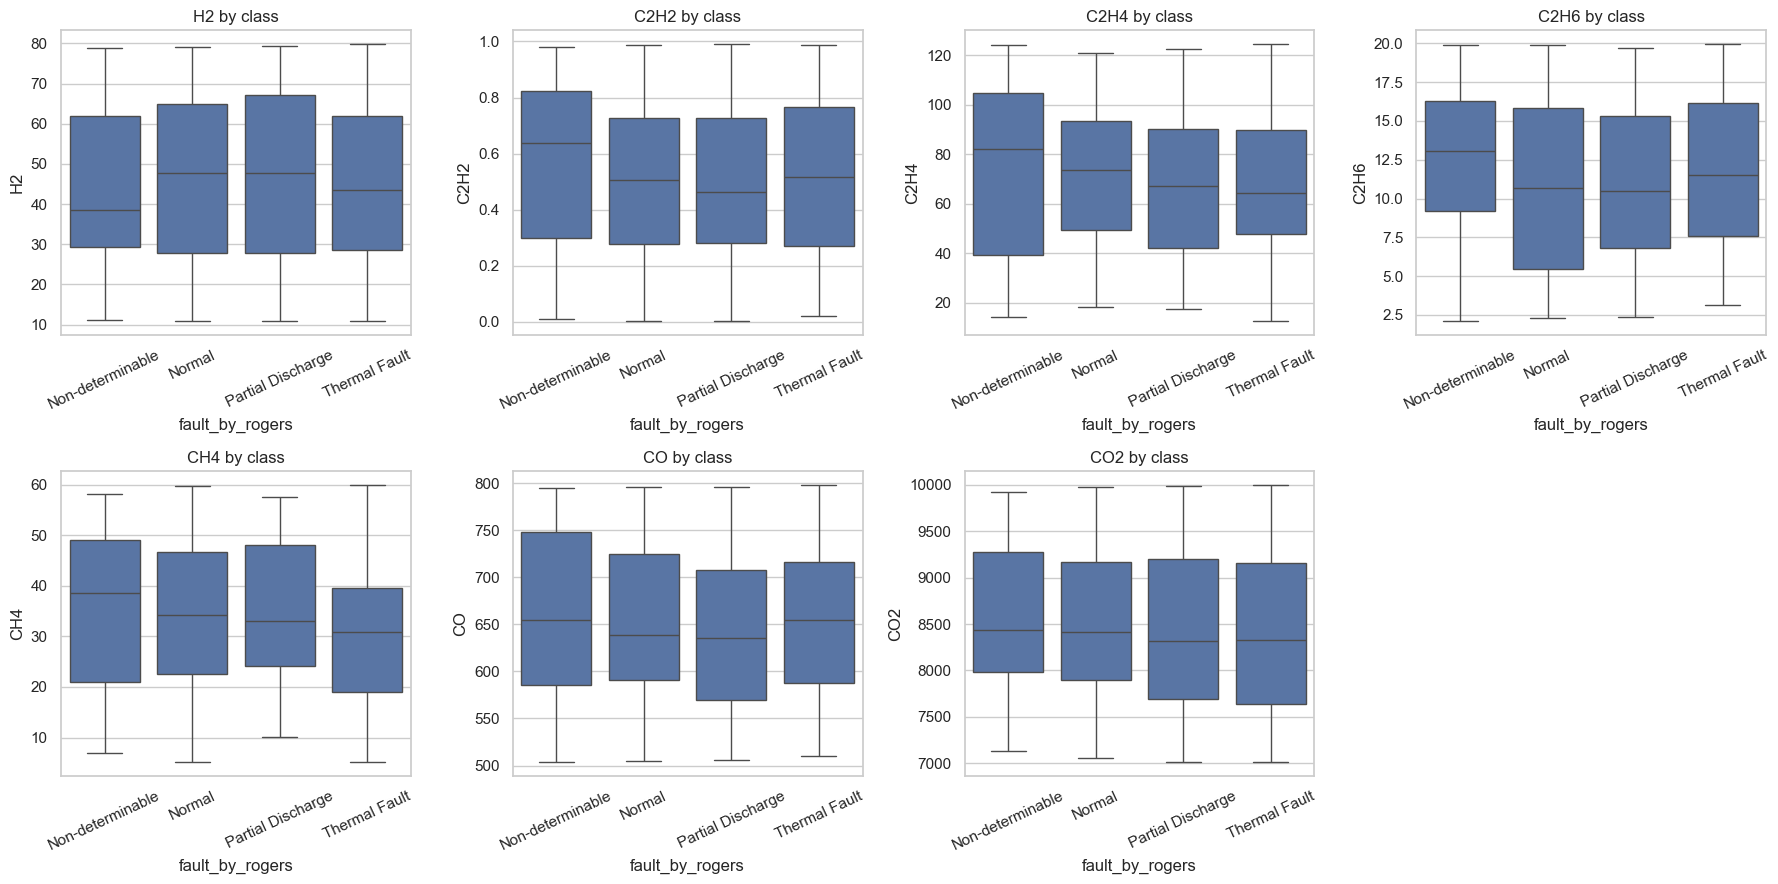

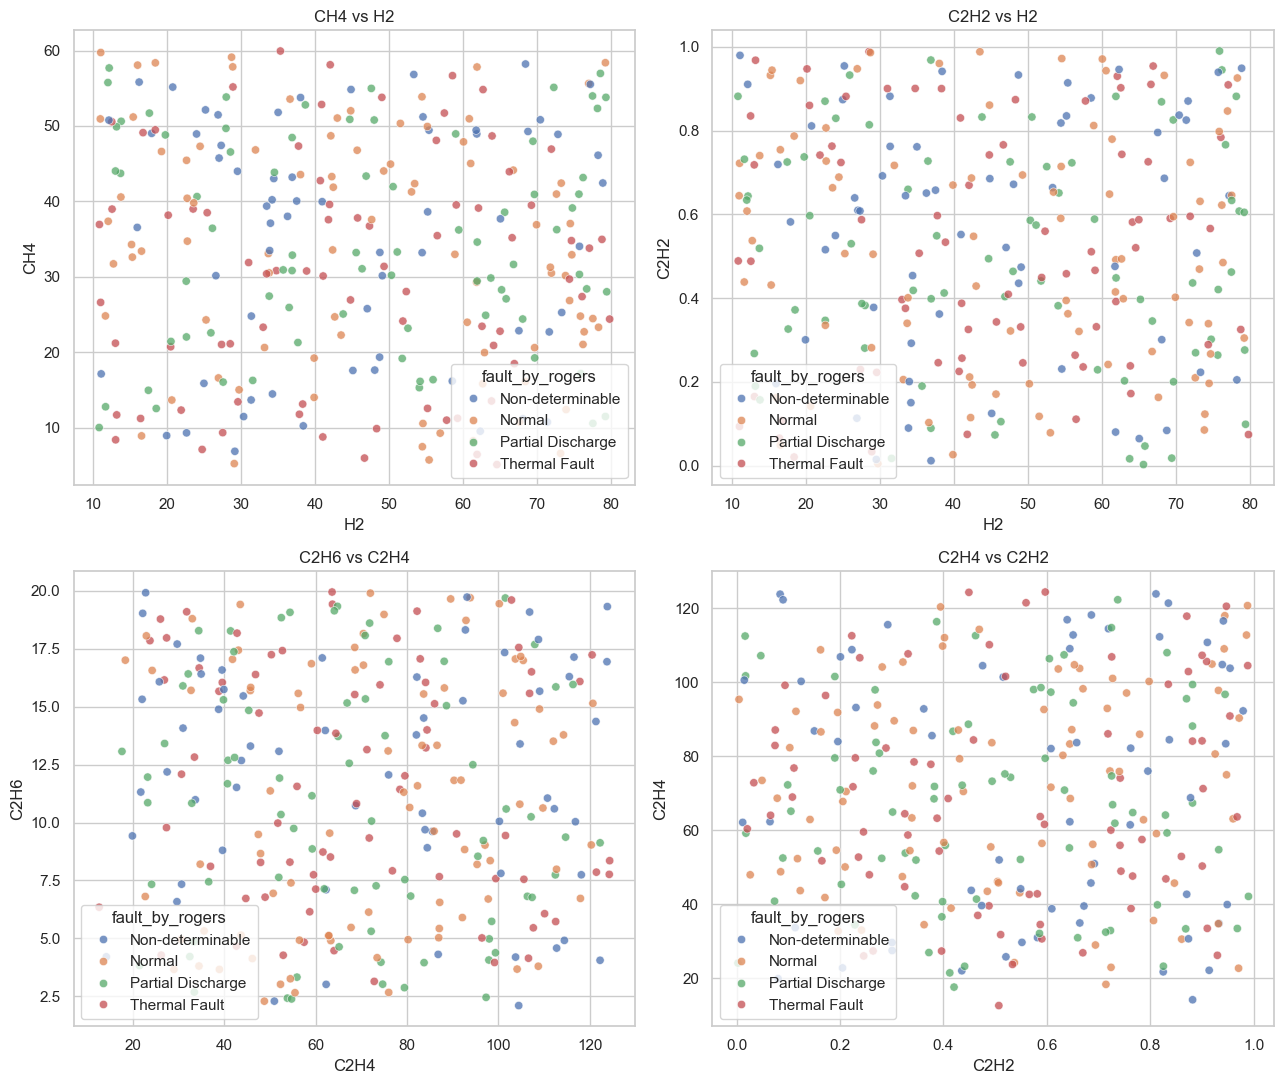

In [12]:
# ============================================================
# 3. Feature separability
# ============================================================

print("=" * 70)
print("3. FEATURE SEPARABILITY")
print("=" * 70)

# ------------------------------------------------------------
# Boxplots
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
)

for ax, feature in zip(axes.flat, RAW_FEATURES):

    sns.boxplot(
        data=df,
        x=TARGET,
        y=feature,
        order=classes,
        showfliers=False,
        ax=ax,
    )

    ax.set_title(f"{feature} by class")
    ax.tick_params(axis="x", rotation=25)

# Hide unused subplot
axes.flat[-1].axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Pairwise scatter plots
# ------------------------------------------------------------

scatter_pairs = [
    ("H2", "CH4"),
    ("H2", "C2H2"),
    ("C2H4", "C2H6"),
    ("C2H2", "C2H4"),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 11),
)

for ax, (x_feature, y_feature) in zip(
    axes.flat,
    scatter_pairs,
):

    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue=TARGET,
        hue_order=classes,
        alpha=0.75,
        ax=ax,
    )

    ax.set_title(
        f"{y_feature} vs {x_feature}"
    )

plt.tight_layout()
plt.show()

PCA PC1 + PC2 variance explained: 42.4%


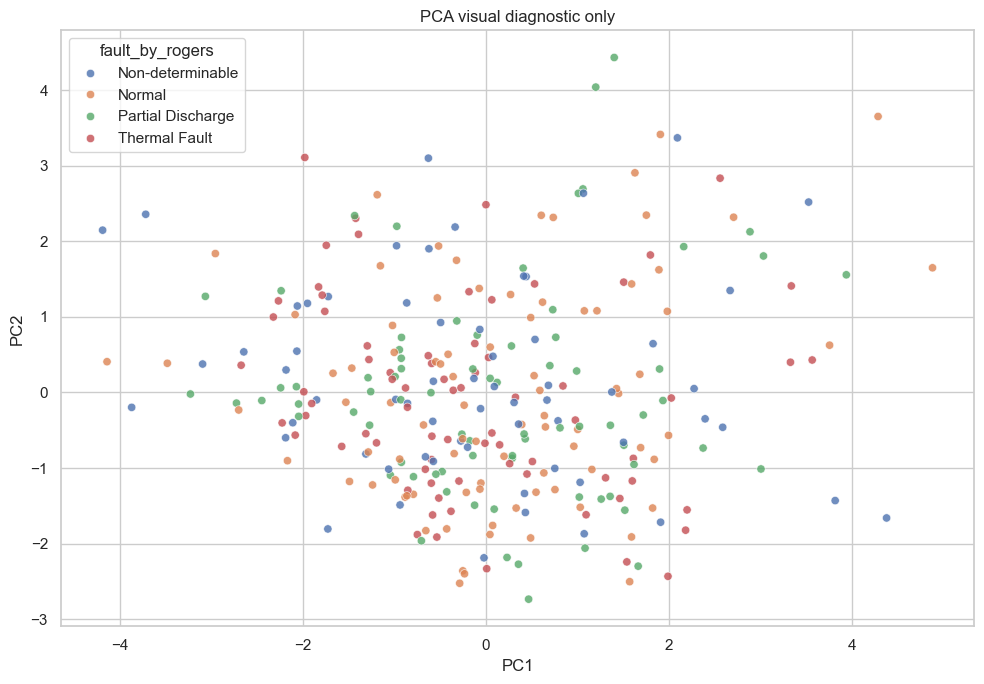

In [13]:
# ============================================================
# PCA diagnostic
# ============================================================

# Median imputation + standardisation
X_scaled = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
).fit_transform(X)

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

principal_components = pca.fit_transform(X_scaled)

explained_variance = (
    pca.explained_variance_ratio_.sum()
)

print(
    f"PCA PC1 + PC2 variance explained: "
    f"{explained_variance:.1%}"
)

pca_df = pd.DataFrame(
    {
        "PC1": principal_components[:, 0],
        "PC2": principal_components[:, 1],
        TARGET: df[TARGET].values,
    }
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=TARGET,
    hue_order=classes,
    alpha=0.8,
)

plt.title("PCA visual diagnostic only")
plt.tight_layout()
plt.show()

### 4. Asset-target relationship
### `asset` is deliberately excluded from the predictive feature set.

4. ASSET-TARGET RELATIONSHIP


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
asset,,,,
TX_A,19,32,22,26
TX_B,21,30,19,26
TX_C,23,25,35,22


Chi-square p-value: 0.3338
Cramer's V: 0.107


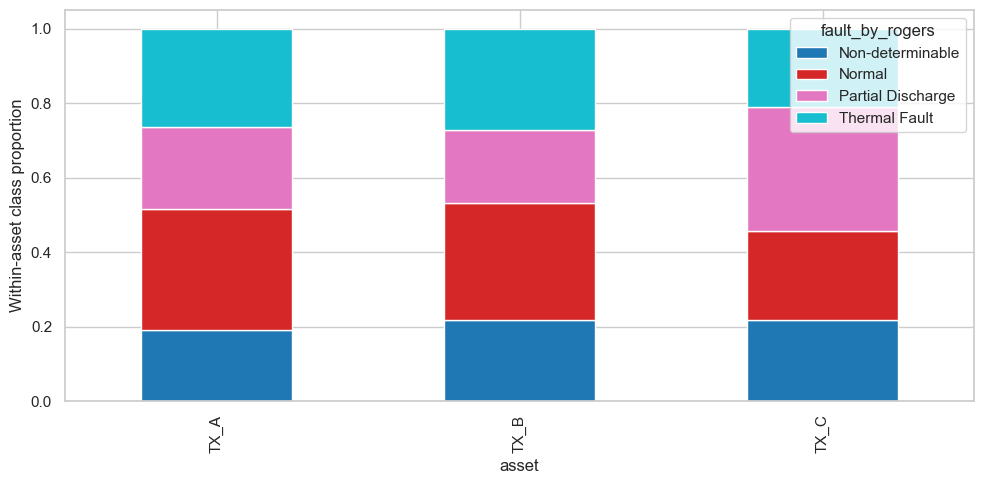

In [14]:
# ============================================================
# 4. Asset-target relationship
# ============================================================

print("=" * 70)
print("4. ASSET-TARGET RELATIONSHIP")
print("=" * 70)

asset_target_table = pd.crosstab(
    df[ASSET],
    df[TARGET],
).reindex(
    columns=classes,
    fill_value=0,
)

chi_square, p_value, _, _ = chi2_contingency(
    asset_target_table
)

n = asset_target_table.to_numpy().sum()

cramers_v = np.sqrt(
    (chi_square / n)
    / min(
        asset_target_table.shape[0] - 1,
        asset_target_table.shape[1] - 1,
    )
)

display(asset_target_table)

print(f"Chi-square p-value: {p_value:.4g}")
print(f"Cramer's V: {cramers_v:.3f}")


# ------------------------------------------------------------
# Within-asset class proportions
# ------------------------------------------------------------

asset_target_proportions = (
    asset_target_table
    .div(asset_target_table.sum(axis=1), axis=0)
)

asset_target_proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    colormap="tab10",
)

plt.ylabel("Within-asset class proportion")
plt.tight_layout()
plt.show()

### 5. Temporal structure

### The timestamp is inspected for temporal clustering and changes in
### class composition. It is not used as a model feature.

5. TEMPORAL STRUCTURE


,count,min,max
asset,,,
TX_A,99,2025-01-01 00:00:00,2025-01-13 10:00:00
TX_B,96,2025-01-01 01:00:00,2025-01-13 09:00:00
TX_C,105,2025-01-01 02:00:00,2025-01-13 11:00:00


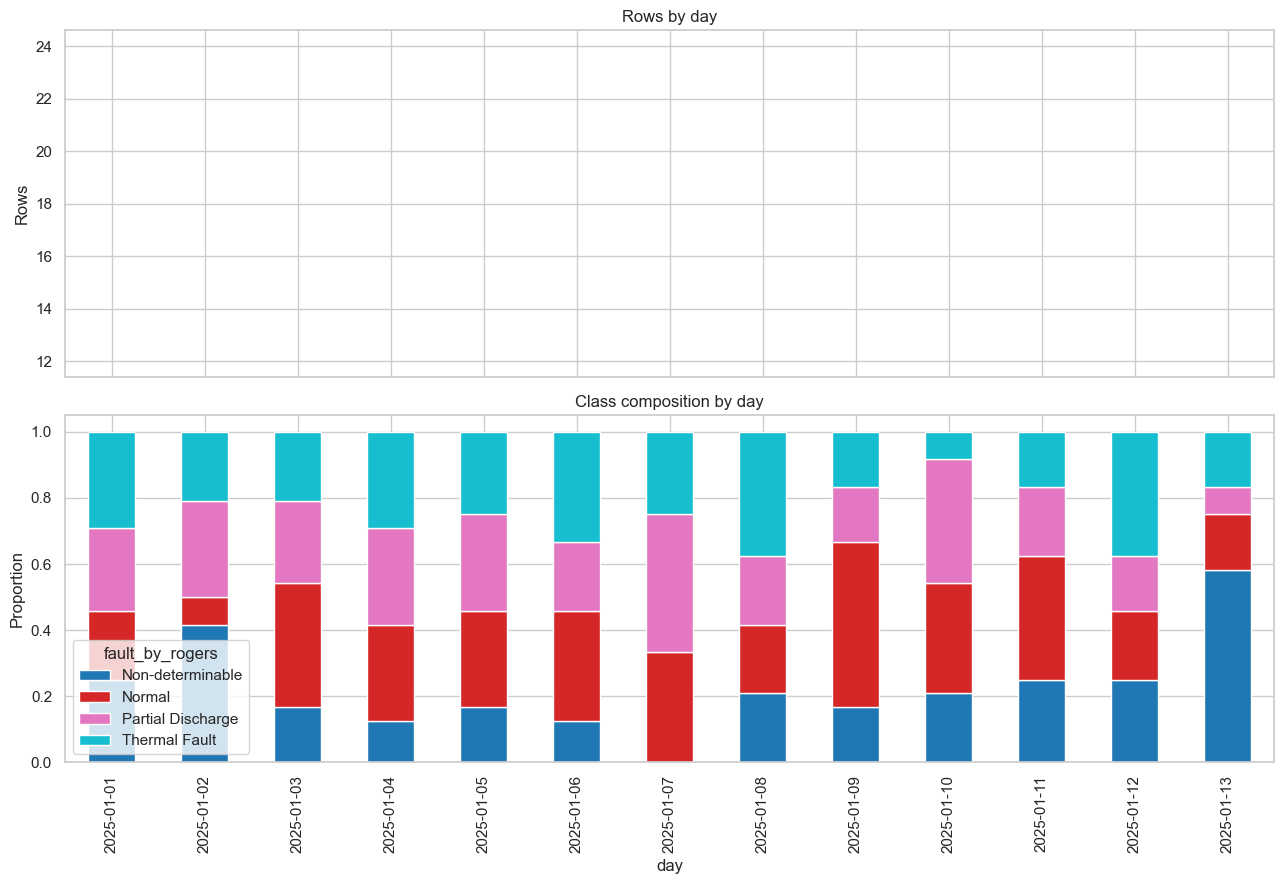

Chronologically adjacent rows from the same asset: 34.8%


In [15]:
# ============================================================
# 5. Temporal diagnostics
# ============================================================

print("=" * 70)
print("5. TEMPORAL STRUCTURE")
print("=" * 70)

# ------------------------------------------------------------
# Time range by asset
# ------------------------------------------------------------

display(
    df.groupby(ASSET)[TIMESTAMP]
    .agg(["count", "min", "max"])
)


# ------------------------------------------------------------
# Prepare chronological data
# ------------------------------------------------------------

chronological_df = (
    df[[TIMESTAMP, ASSET, TARGET]]
    .sort_values(TIMESTAMP)
    .copy()
)

chronological_df["day"] = (
    chronological_df[TIMESTAMP].dt.date
)


# ------------------------------------------------------------
# Rows per day + class composition
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True,
)

chronological_df.groupby("day").size().plot(
    ax=axes[0],
    marker="o",
)

axes[0].set_title("Rows by day")
axes[0].set_ylabel("Rows")


daily_class_distribution = (
    pd.crosstab(
        chronological_df["day"],
        chronological_df[TARGET],
        normalize="index",
    )
    .reindex(columns=classes, fill_value=0)
)

daily_class_distribution.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    colormap="tab10",
)

axes[1].set_title("Class composition by day")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Adjacent rows from same asset
# ------------------------------------------------------------

assets_chronological = chronological_df[ASSET].to_numpy()

same_asset_rate = (
    assets_chronological[1:]
    == assets_chronological[:-1]
).mean()

print(
    "Chronologically adjacent rows from the same asset: "
    f"{same_asset_rate:.1%}"
)

### 6. Fixed XGBoost model

### No hyperparameter tuning is performed in V2.

### The model is intentionally fixed so that the validation results represent
### an initial evidence check rather than an optimisation exercise.

In [16]:
# ============================================================
# 6. Fixed XGBoost model
# ============================================================

def create_model():
    """
    Create the fixed XGBoost pipeline used throughout V2.
    """

    return Pipeline(
        [
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                XGBClassifier(
                    objective="multi:softprob",
                    num_class=len(classes),
                    n_estimators=150,
                    max_depth=3,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    reg_lambda=1.0,
                    eval_metric="mlogloss",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    tree_method="hist",
                ),
            ),
        ]
    )


# ------------------------------------------------------------
# Cross-validation configuration
# ------------------------------------------------------------

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE,
)

SCORING = {
    "f1": "f1_macro",
    "accuracy": "accuracy",
    "balanced": "balanced_accuracy",
}

### 7. Repeated stratified cross-validation

### 5 folds × 5 repeats = 25 validation estimates.

### A majority-class baseline is included for comparison.

In [17]:
# ============================================================
# 7. Repeated stratified cross-validation
# ============================================================

print("=" * 70)
print("7. REPEATED STRATIFIED CROSS-VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb_results = cross_validate(
    create_model(),
    X,
    y,
    cv=cv,
    scoring=SCORING,
    return_train_score=True,
    n_jobs=-1,
)


# ------------------------------------------------------------
# Majority baseline
# ------------------------------------------------------------

baseline_results = cross_validate(
    DummyClassifier(strategy="most_frequent"),
    X,
    y,
    cv=cv,
    scoring=SCORING,
    return_train_score=True,
    n_jobs=-1,
)


# ------------------------------------------------------------
# Summarise results
# ------------------------------------------------------------

def summarise_cv_results(name, results):
    """
    Summarise repeated cross-validation results.
    """

    validation_f1 = results["test_f1"].mean()
    training_f1 = results["train_f1"].mean()

    return [
        name,
        validation_f1,
        results["test_f1"].std(ddof=1),
        training_f1,
        training_f1 - validation_f1,
        results["test_accuracy"].mean(),
        results["test_balanced"].mean(),
    ]


cv_summary = pd.DataFrame(
    [
        summarise_cv_results(
            "Fixed XGBoost",
            xgb_results,
        ),
        summarise_cv_results(
            "Majority baseline",
            baseline_results,
        ),
    ],
    columns=[
        "model",
        "validation_macro_f1",
        "fold_sd",
        "train_macro_f1",
        "gap",
        "accuracy",
        "balanced_accuracy",
    ],
)

display(cv_summary.round(4))

7. REPEATED STRATIFIED CROSS-VALIDATION


,model,validation_macro_f1,fold_sd,train_macro_f1,gap,accuracy,balanced_accuracy
0,Fixed XGBoost,0.2590,0.0421,0.9895,0.7305,0.2647,0.2618
1,Majority baseline,0.1124,0.0025,0.1124,0.0000,0.2900,0.2500


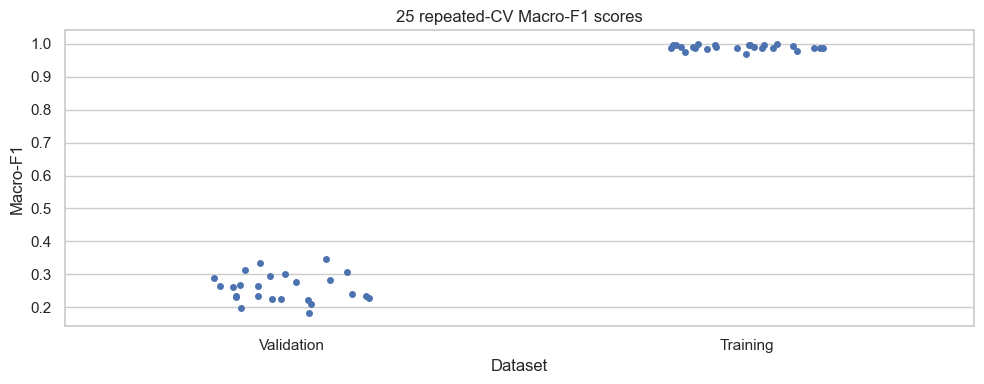

In [18]:
# ============================================================
# Cross-validation score distribution
# ============================================================

cv_scores = pd.DataFrame(
    {
        "Validation": xgb_results["test_f1"],
        "Training": xgb_results["train_f1"],
    }
).melt(
    var_name="Dataset",
    value_name="Macro-F1",
)

plt.figure(figsize=(10, 4))

sns.stripplot(
    data=cv_scores,
    x="Dataset",
    y="Macro-F1",
    jitter=0.18,
)

plt.title("25 repeated-CV Macro-F1 scores")
plt.tight_layout()
plt.show()

### 8. Permutation-label control

### The target labels are randomly permuted 100 times.

### The exact same model and cross-validation procedure are then applied.
### This provides a null distribution for comparison with the observed score.

In [20]:
# ============================================================
# 8. Permutation-label control
# ============================================================

print("=" * 70)
print("8. PERMUTATION-LABEL CONTROL")
print("=" * 70)

permutation_scores = []

for seed in range(
    RANDOM_STATE,
    RANDOM_STATE + N_PERMUTATIONS,
):

    rng = np.random.default_rng(seed)

    permuted_y = rng.permutation(y)

    result = cross_validate(
        create_model(),
        X,
        permuted_y,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )

    permutation_scores.append(
        result["test_score"].mean()
    )

permutation_scores = np.asarray(
    permutation_scores
)


# ------------------------------------------------------------
# Compare observed and null distributions
# ------------------------------------------------------------

real_macro_f1 = (
    xgb_results["test_f1"].mean()
)

null_mean = permutation_scores.mean()
null_sd = permutation_scores.std(ddof=1)

null_95th_percentile = np.quantile(
    permutation_scores,
    0.95,
)

empirical_p_value = (
    1 + np.sum(
        permutation_scores >= real_macro_f1
    )
) / (N_PERMUTATIONS + 1)


permutation_summary = pd.DataFrame(
    [
        [
            real_macro_f1,
            null_mean,
            null_sd,
            null_95th_percentile,
            empirical_p_value,
        ]
    ],
    columns=[
        "real_mean",
        "mean",
        "standard deviation",
        "95th percentile",
        "empirical one sided",
    ],
)

display(permutation_summary.round(4))

8. PERMUTATION-LABEL CONTROL


,real_mean,mean,standard deviation,95th percentile,empirical one sided
0,0.259,0.2461,0.0253,0.2831,0.2871


### 9. Representation robustness

### Three feature representations are evaluated using the same repeated
### cross-validation procedure:

### - Raw DGA variables
### - Raw DGA + ratios
### - Ratios only

In [21]:
# ============================================================
# 9. Representation robustness
# ============================================================

print("=" * 70)
print("9. REPRESENTATION ROBUSTNESS")
print("=" * 70)

representations = {
    "Raw DGA": RAW_FEATURES,
    "Raw + ratios": FEATURES,
    "Ratios only": RATIO_FEATURES,
}

representation_results = []

for name, feature_set in representations.items():

    result = cross_validate(
        create_model(),
        df[feature_set],
        y,
        cv=cv,
        scoring="f1_macro",
        return_train_score=True,
        n_jobs=-1,
    )

    test_f1 = result["test_score"].mean()
    train_f1 = result["train_score"].mean()

    representation_results.append(
        [
            name,
            test_f1,
            train_f1 - test_f1,
        ]
    )


representation_table = pd.DataFrame(
    representation_results,
    columns=[
        "representation",
        "repeated_cv_macro_f1",
        "gap",
    ],
).sort_values(
    "repeated_cv_macro_f1",
    ascending=False,
)

display(
    representation_table.round(4)
)

9. REPRESENTATION ROBUSTNESS


,representation,repeated_cv_macro_f1,gap
1,Raw + ratios,0.2590,0.7305
0,Raw DGA,0.2580,0.7182
2,Ratios only,0.2072,0.6558


### 10. Leave-one-asset-out validation

### Each asset is held out in turn.

### This tests whether the model's performance depends strongly on having
### observations from the same asset in both training and validation sets.

In [22]:
# ============================================================
# 10. Leave-one-asset-out validation
# ============================================================

print("=" * 70)
print("10. LEAVE-ONE-ASSET-OUT VALIDATION")
print("=" * 70)

asset_results = []

for held_out_asset in sorted(df[ASSET].unique()):

    train_mask = df[ASSET].ne(
        held_out_asset
    )

    test_mask = ~train_mask

    # XGBoost
    model = create_model()

    model.fit(
        X[train_mask],
        y[train_mask],
    )

    # Majority baseline
    baseline = DummyClassifier(
        strategy="most_frequent"
    )

    baseline.fit(
        X[train_mask],
        y[train_mask],
    )

    # Predictions
    train_predictions = model.predict(
        X[train_mask]
    )

    test_predictions = model.predict(
        X[test_mask]
    )

    baseline_predictions = baseline.predict(
        X[test_mask]
    )

    asset_results.append(
        [
            held_out_asset,
            train_mask.sum(),
            test_mask.sum(),
            f1_score(
                y[train_mask],
                train_predictions,
                average="macro",
                labels=labels,
                zero_division=0,
            ),
            f1_score(
                y[test_mask],
                test_predictions,
                average="macro",
                labels=labels,
                zero_division=0,
            ),
            f1_score(
                y[test_mask],
                baseline_predictions,
                average="macro",
                labels=labels,
                zero_division=0,
            ),
        ]
    )


asset_table = pd.DataFrame(
    asset_results,
    columns=[
        "held_out_asset",
        "train_n",
        "test_n",
        "train_macro_f1",
        "test_macro_f1",
        "majority_test_macro_f1",
    ],
)

display(asset_table.round(4))

10. LEAVE-ONE-ASSET-OUT VALIDATION


,held_out_asset,train_n,test_n,train_macro_f1,test_macro_f1,majority_test_macro_f1
0,TX_A,201,99,0.9848,0.2514,0.1221
1,TX_B,204,96,0.9956,0.1989,0.1190
2,TX_C,195,105,0.9854,0.2245,0.0962


### 11. Chronological 70/30 holdout

### The earliest 70% of observations are used for training and the latest
### 30% are used for testing.

### This is a diagnostic check for temporal generalisation.

In [23]:
# ============================================================
# 11. Chronological 70/30 holdout
# ============================================================

print("=" * 70)
print("11. CHRONOLOGICAL 70/30 HOLDOUT")
print("=" * 70)

# Sort by timestamp
chronological_indices = (
    df.sort_values(TIMESTAMP).index.to_numpy()
)

split_index = int(
    0.70 * len(chronological_indices)
)

train_indices = chronological_indices[:split_index]
test_indices = chronological_indices[split_index:]


# ------------------------------------------------------------
# Train XGBoost
# ------------------------------------------------------------

chronological_model = create_model()

chronological_model.fit(
    X.loc[train_indices],
    y[train_indices],
)


# ------------------------------------------------------------
# Train majority baseline
# ------------------------------------------------------------

chronological_baseline = DummyClassifier(
    strategy="most_frequent"
)

chronological_baseline.fit(
    X.loc[train_indices],
    y[train_indices],
)


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

train_predictions = chronological_model.predict(
    X.loc[train_indices]
)

test_predictions = chronological_model.predict(
    X.loc[test_indices]
)

baseline_predictions = chronological_baseline.predict(
    X.loc[test_indices]
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

chronological_results = pd.DataFrame(
    [
        [
            len(train_indices),
            len(test_indices),
            f1_score(
                y[train_indices],
                train_predictions,
                average="macro",
                labels=labels,
                zero_division=0,
            ),
            f1_score(
                y[test_indices],
                test_predictions,
                average="macro",
                labels=labels,
                zero_division=0,
            ),
            f1_score(
                y[test_indices],
                baseline_predictions,
                average="macro",
                labels=labels,
                zero_division=0,
            ),
            accuracy_score(
                y[test_indices],
                test_predictions,
            ),
            balanced_accuracy_score(
                y[test_indices],
                test_predictions,
            ),
        ]
    ],
    columns=[
        "train_n",
        "test_n",
        "train_macro_f1",
        "test_macro_f1",
        "majority_test_macro_f1",
        "test_accuracy",
        "test_balanced_accuracy",
    ],
)

display(
    chronological_results.round(4)
)

11. CHRONOLOGICAL 70/30 HOLDOUT


,train_n,test_n,train_macro_f1,test_macro_f1,majority_test_macro_f1,test_accuracy,test_balanced_accuracy
0,210,90,0.9945,0.1943,0.1154,0.2667,0.2554


### 12. Conservative XGBoost tuning gate

### Tuning is considered only if all predefined evidence checks pass.

### These thresholds are deliberately specified before tuning so that the
### decision is not changed after observing the results.

In [24]:
# ============================================================
# 12. Conservative tuning gate
# ============================================================

majority_macro_f1 = (
    baseline_results["test_f1"].mean()
)

training_validation_gap = (
    xgb_results["train_f1"].mean()
    - real_macro_f1
)

asset_model_f1 = (
    asset_table["test_macro_f1"].mean()
)

asset_baseline_f1 = (
    asset_table["majority_test_macro_f1"].mean()
)

best_representation_f1 = (
    representation_table.iloc[0]["repeated_cv_macro_f1"]
)

chronological_model_f1 = (
    chronological_results.loc[
        0,
        "test_macro_f1",
    ]
)

chronological_baseline_f1 = (
    chronological_results.loc[
        0,
        "majority_test_macro_f1",
    ]
)


# ------------------------------------------------------------
# Gate conditions
# ------------------------------------------------------------

gate_results = pd.DataFrame(
    [
        [
            "Real exceeds permutation null",
            (
                real_macro_f1 > null_95th_percentile
                and empirical_p_value < 0.05
            ),
            (
                f"real={real_macro_f1:.4f}; "
                f"null 95th={null_95th_percentile:.4f}; "
                f"p={empirical_p_value:.4f}"
            ),
        ],
        [
            "Meaningfully exceeds majority baseline",
            (
                real_macro_f1
                - majority_macro_f1
                >= 0.05
            ),
            (
                f"margin="
                f"{real_macro_f1 - majority_macro_f1:.4f}; "
                "threshold=0.0500"
            ),
        ],
        [
            "Some representation exceeds permutation null",
            best_representation_f1 > null_95th_percentile,
            (
                f"best="
                f"{representation_table.iloc[0]['representation']}; "
                f"score={best_representation_f1:.4f}"
            ),
        ],
        [
            "No substantial memorisation",
            training_validation_gap <= 0.20,
            (
                f"gap={training_validation_gap:.4f}; "
                "threshold<=0.2000"
            ),
        ],
        [
            "Asset and time robustness exceed baselines",
            (
                asset_model_f1 > asset_baseline_f1
                and chronological_model_f1
                > chronological_baseline_f1
            ),
            (
                f"asset="
                f"{asset_model_f1:.4f}/"
                f"{asset_baseline_f1:.4f}; "
                f"time="
                f"{chronological_model_f1:.4f}/"
                f"{chronological_baseline_f1:.4f}"
            ),
        ],
    ],
    columns=[
        "condition",
        "pass",
        "evidence",
    ],
)

print(
    "\nXGBoost tuning gate — all conditions must pass"
)

display(
    gate_results
)


XGBoost tuning gate — all conditions must pass


,condition,pass,evidence
0,Real exceeds permutation null,False,real=0.2590; null 95th=0.2831; p=0.2871
1,Meaningfully exceeds majority baseline,True,margin=0.1467; threshold=0.0500
2,Some representation exceeds permutation null,False,best=Raw + ratios; score=0.2590
3,No substantial memorisation,False,gap=0.7305; threshold<=0.2000
4,Asset and time robustness exceed baselines,True,asset=0.2249/0.1124; time=0.1943/0.1154


### 13. V2 conclusion

In [25]:
# ============================================================
# 13. V2 CONCLUSION
# ============================================================

all_conditions_pass = (
    gate_results["pass"].all()
)

if all_conditions_pass:

    conclusion = (
        "GO — isolated/nested XGBoost tuning is justified in V3."
    )

elif (
    real_macro_f1 > null_mean
    and real_macro_f1 > majority_macro_f1
):

    conclusion = (
        "INVESTIGATE — evidence is weak or unstable. "
        "Review target construction, feature overlap, "
        "asset effects, and temporal effects before tuning."
    )

else:

    conclusion = (
        "NO-GO / DATA-TARGET REVIEW — "
        "no reproducible DGA-to-fault-class signal was "
        "demonstrated; tuning is not scientifically justified."
    )


print("=" * 72)
print("V2 CONCLUSION")
print("=" * 72)
print(conclusion)
print("=" * 72)

V2 CONCLUSION
INVESTIGATE — evidence is weak or unstable. Review target construction, feature overlap, asset effects, and temporal effects before tuning.
